In [1]:
# ============================================================
# AI vs Human Text Detection
# Install Required Libraries
# ============================================================

!pip install -q transformers datasets accelerate
!pip install -q pandas numpy scikit-learn matplotlib seaborn tqdm

In [4]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

import torch
import torchvision
import datasets
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import transformers
from transformers import (AutoTokenizer, AutoModelForSequenceClassification)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
import random

In [5]:
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Torch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

Transformers: 5.0.0
Datasets: 4.0.0
Torch: 2.11.0+cu128
TorchVision: 0.26.0+cu128


In [6]:
# ============================================================
# Set Random Seeds
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed Set Successfully")

Seed Set Successfully


In [7]:
# ==========================================
# Check GPU Availability
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Using Device: cuda
GPU Name: Tesla T4


In [8]:
# ============================================================
# Load AI Text Detection Dataset
# ============================================================

dataset = load_dataset(
    "artem9k/ai-text-detection-pile"
)

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

data/train-00000-of-00007-bc5952582e004d(…):   0%|          | 0.00/758M [00:00<?, ?B/s]

data/train-00001-of-00007-71c80017bc45f3(…):   0%|          | 0.00/318M [00:00<?, ?B/s]

data/train-00002-of-00007-ee2d43f396e78f(…):   0%|          | 0.00/125M [00:00<?, ?B/s]

...

data/train-00004-of-00007-b269dc49374a2c(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

data/train-00005-of-00007-3dce5e05ddbad7(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

data/train-00006-of-00007-3d8a471ba0cf1c(…):   0%|          | 0.00/242M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1392522 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['source', 'id', 'text'],
        num_rows: 1392522
    })
})


In [9]:
# ============================================================
# Convert Dataset to Pandas DataFrame
# ============================================================

df = dataset["train"].to_pandas()
print("Shape:", df.shape)
df.head()

Shape: (1392522, 3)


,source,id,text
0,human,0,12 Years a Slave: An Analysis of the Film Essa...
1,human,1,20+ Social Media Post Ideas to Radically Simpl...
2,human,2,2022 Russian Invasion of Ukraine in Global Med...
3,human,3,533 U.S. 27 (2001) Kyllo v. United States: The...
4,human,4,A Charles Schwab Corporation Case Essay\n\nCha...


In [10]:
# ============================================================
# Dataset Exploration
# ============================================================

print(df.columns)
print("\nSource Distribution:")
print(df["source"].value_counts())

Index(['source', 'id', 'text'], dtype='object')

Source Distribution:
source
human    1028146
ai        364376
Name: count, dtype: int64


In [11]:
# ============================================================
# Convert Labels to Numeric Format
# ============================================================
# human -> 0
# ai -> 1

label_map = {"human": 0, "ai": 1}
df["label"] = df["source"].map(label_map)
print(df["label"].value_counts())

label
0    1028146
1     364376
Name: count, dtype: int64


In [47]:
# ============================================================
# Create Balanced Dataset
# ============================================================

human_df = df[df["label"] == 0].sample(25000, random_state=SEED)

ai_df = df[df["label"] == 1].sample(25000, random_state=SEED)

balanced_df = pd.concat([human_df, ai_df])

balanced_df = balanced_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(balanced_df.shape)

print(balanced_df["label"].value_counts())

(50000, 4)
label
1    25000
0    25000
Name: count, dtype: int64


In [48]:
# ============================================================
# Basic Text Cleaning
# ============================================================

balanced_df = balanced_df.dropna(subset=["text"])

balanced_df["text"] = (balanced_df["text"].astype(str).str.strip())

balanced_df = balanced_df[balanced_df["text"].str.len() > 0]

balanced_df = balanced_df[balanced_df["text"].apply(
        lambda x: len(x.split()) > 20
    )]

balanced_df = balanced_df.reset_index(drop=True)

print("Final Shape:")
print(balanced_df.shape)

Final Shape:
(49251, 4)


In [49]:
# ============================================================
# Train Validation Test Split
# ============================================================

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    balanced_df["text"],
    balanced_df["label"],
    test_size=0.2,
    random_state=SEED,
    stratify=balanced_df["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))

Training Samples: 39400
Validation Samples: 4925
Test Samples: 4926


In [50]:
#-------------------------------------------
# LOAD TOKENIZER
#-------------------------------------------
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [51]:
print(type(tokenizer))
print(tokenizer.name_or_path)

<class 'transformers.models.bert.tokenization_bert.BertTokenizer'>
distilbert-base-uncased


In [52]:
# ============================================================
# Custom PyTorch Dataset
# ============================================================

MAX_LENGTH = 128
class AITextDataset(Dataset):
    def __init__(
        self,
        texts,
        labels,
        tokenizer
    ):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = self.tokenizer(text, truncation=True, padding="max_length", max_length=MAX_LENGTH, return_tensors="pt")

        return {

            "input_ids":
                encoding["input_ids"].squeeze(0),

            "attention_mask":
                encoding["attention_mask"].squeeze(0),

            "labels":
                torch.tensor(
                    self.labels[idx],
                    dtype=torch.long
                )
        }

In [53]:
# ==========================================
# Creating dataset objects
# ==========================================

train_dataset = AITextDataset(
    train_texts,
    train_labels,
    tokenizer
)

val_dataset = AITextDataset(
    val_texts,
    val_labels,
    tokenizer
)

test_dataset = AITextDataset(
    test_texts,
    test_labels,
    tokenizer
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

39400
4925
4926


In [54]:
# ==========================================
# Creating Data Loaders
# ==========================================
BATCH_SIZE = 16
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [55]:
# ============================================================
# Verify DataLoader
# ============================================================

batch = next(iter(train_loader))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([16, 128])
torch.Size([16, 128])
torch.Size([16])


In [56]:
# ==========================================
# Load DistilBert Model
# ==========================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [57]:
# ============================================================
# Optimizer
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5
)

print("Optimizer Ready")

Optimizer Ready


In [58]:
# ============================================================
# Validation Function
# ============================================================

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss

            total_loss += loss.item()

            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)

    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    return (
        avg_loss,
        accuracy,
        precision,
        recall,
        f1
    )

In [59]:
# ==========================================
# Training Loop
# ==========================================

EPOCHS = 3

train_losses = []
val_losses = []

best_f1 = 0
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    model.train()
    total_train_loss = 0
    progress_bar = tqdm(train_loader)
    for batch in progress_bar:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()
        progress_bar.set_postfix(
            {"loss": loss.item()}
        )

    avg_train_loss = (total_train_loss / len(train_loader))
    train_losses.append(avg_train_loss)

    (
        val_loss,
        val_acc,
        val_precision,
        val_recall,
        val_f1
    ) = evaluate_model(
        model,
        val_loader
    )

    val_losses.append(val_loss)

    print(f"Train Loss: {avg_train_loss:.4f}")

    print(f"Val Loss: {val_loss:.4f}")

    print(f"Val Accuracy: {val_acc:.4f}")

    print(f"Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_distilbert_ai_detector.pt")
        print("Best model saved.")


Epoch 1/3


100%|██████████| 2463/2463 [09:57<00:00,  4.13it/s, loss=0.0267]


Train Loss: 0.1739
Val Loss: 0.1425
Val Accuracy: 0.9409
Val F1: 0.9423
Best model saved.

Epoch 2/3


100%|██████████| 2463/2463 [09:55<00:00,  4.14it/s, loss=0.00267]


Train Loss: 0.0645
Val Loss: 0.1532
Val Accuracy: 0.9486
Val F1: 0.9498
Best model saved.

Epoch 3/3


100%|██████████| 2463/2463 [09:56<00:00,  4.13it/s, loss=0.0341]


Train Loss: 0.0248
Val Loss: 0.1423
Val Accuracy: 0.9509
Val F1: 0.9506
Best model saved.


In [60]:
# ==========================================
# Load Best Model
# ==========================================

model.load_state_dict(
    torch.load(
        "best_distilbert_ai_detector.pt"
    )
)
print("Best Model Loaded")

Best Model Loaded


In [61]:
# ==========================================
# Model Evaluation
# ==========================================

test_loss, test_acc, test_prec, test_rec, test_f1 = evaluate_model(model, test_loader)

print("\nTEST RESULTS")

print("Accuracy :", test_acc)
print(f"Loss: {test_loss:.4f}")
print("Precision:", test_prec)
print("Recall   :", test_rec)
print("F1 Score :", test_f1)


TEST RESULTS
Accuracy : 0.9545269995939911
Loss: 0.1402
Precision: 0.9459677419354838
Recall   : 0.9630541871921182
F1 Score : 0.9544344995931652


In [62]:
# ==========================================
# Generate Predictions
# ==========================================

model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

100%|██████████| 308/308 [00:27<00:00, 11.33it/s]


In [63]:
# ==========================================
# Classification Report
# ==========================================

print(classification_report(all_labels, all_preds, target_names=["Human", "AI"]))

              precision    recall  f1-score   support

       Human       0.96      0.95      0.95      2490
          AI       0.95      0.96      0.95      2436

    accuracy                           0.95      4926
   macro avg       0.95      0.95      0.95      4926
weighted avg       0.95      0.95      0.95      4926



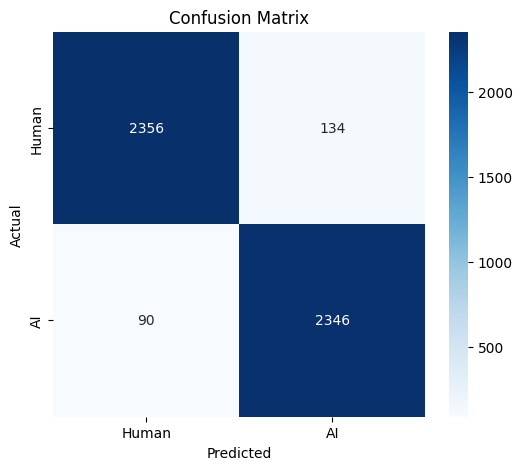

In [64]:
#===============================================
# Confusion Matrix
#===============================================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Human","AI"],
    yticklabels=["Human","AI"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [65]:
def predict_text(text):

    model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    with torch.no_grad():

        outputs = model(
            input_ids=encoding["input_ids"].to(device),
            attention_mask=encoding["attention_mask"].to(device)
        )

        probs = torch.softmax(
            outputs.logits,
            dim=1
        )

        print("Human Probability:", probs[0][0].item())
        print("AI Probability   :", probs[0][1].item())

        pred = torch.argmax(probs).item()

        print(
            "Prediction:",
            "Human" if pred == 0 else "AI"
        )

In [66]:
human_text_1 = """
The Taj Mahal is an ivory-white marble mausoleum located in Agra, India.
It was commissioned in 1632 by the Mughal emperor Shah Jahan in memory
of his wife Mumtaz Mahal. The monument is widely regarded as one of the
finest examples of Mughal architecture and attracts millions of visitors
every year.
"""

predict_text(human_text_1)

Human Probability: 0.010761471465229988
AI Probability   : 0.9892385005950928
Prediction: AI


In [67]:
human_text_2 = """
Yesterday I missed my train because I woke up late. I had been working
on a project until almost midnight and forgot to set an alarm. Although
it was frustrating at the time, I ended up taking a later train and used
the extra time to review some notes for an upcoming interview.
"""

predict_text(human_text_2)

Human Probability: 0.9862686991691589
AI Probability   : 0.013731241226196289
Prediction: Human


In [68]:
human_text_3 = """
I've been using Linux for about two years now. The learning curve was
definitely steep in the beginning, but after getting comfortable with
the terminal I found it much easier to automate repetitive tasks.
"""
predict_text(human_text_3)

Human Probability: 0.028059178963303566
AI Probability   : 0.9719407558441162
Prediction: AI


In [69]:
ai_text_1 = """
Artificial intelligence is revolutionizing industries across the globe
by enabling organizations to automate processes, improve efficiency,
and gain deeper insights from data. Businesses that adopt AI-driven
strategies are often better positioned to innovate and remain competitive
in rapidly changing markets.
"""

predict_text(ai_text_1)

Human Probability: 0.5237968564033508
AI Probability   : 0.4762030839920044
Prediction: Human


In [70]:
ai_text_2 = """
Machine learning has become a cornerstone of modern technological
advancement. By leveraging large datasets and sophisticated algorithms,
organizations can uncover patterns, predict outcomes, and optimize
decision-making processes with unprecedented accuracy and speed.
"""

predict_text(ai_text_2)

Human Probability: 0.28095632791519165
AI Probability   : 0.7190436720848083
Prediction: AI


In [71]:
ai_text_3 = """
The future of education will likely involve a combination of traditional
instruction and personalized digital learning experiences. Advanced
analytics and intelligent tutoring systems can help students learn at
their own pace while providing educators with valuable insights into
student performance and engagement.
"""

predict_text(ai_text_3)

Human Probability: 0.06198557838797569
AI Probability   : 0.9380144476890564
Prediction: AI


In [72]:
human_hard = """
The experiment was conducted over a period of six weeks, during which
participants completed a series of cognitive tasks under controlled
conditions. The results indicated a statistically significant improvement
in task performance compared with the baseline measurements.
"""

predict_text(human_hard)

Human Probability: 0.0007199205574579537
AI Probability   : 0.9992801547050476
Prediction: AI


In [38]:
print(label_map)

{'human': 0, 'ai': 1}


In [39]:
human_example = balanced_df[
    balanced_df["label"] == 0
].iloc[0]["text"]

print(human_example[:500])

predict_text(human_example)

s with similar results. What ever was going on last night was not happening this morning. Maybe it was the caffeine I drank the previous day. Was it possible to reach a level of caffeine in my blood that gave me super study abilities? I dashed out of my door, down the steps and out of the dorm complex. 
 
 I ran as fast as I could to the 8-12 and grabbed six tall cans of caffeine taurine and what ever else they can cram into carbonated sugar water. I chugged all six before I was a block away. My
Prediction : Human Written
Confidence : 99.93%


('Human Written', 99.93164539337158)

In [40]:
ai_example = balanced_df[
    balanced_df["label"] == 1
].iloc[0]["text"]

print(ai_example[:500])

predict_text(ai_example)

"She was so beautiful, she could have been my own sister. She was a beautiful little girl - a lot older than I am." This is what I would have said had I heard about Jane to the end of my days in London. But Jane was murdered in September last year and as a result I never met her or saw her again.

There is a simple reason for my silence: I will not make the same mistake again.

"Jane to the end of her days; how can you leave her like that?" And I can't. For the first time in my life I feel safe 
Prediction : AI Generated
Confidence : 99.82%


('AI Generated', 99.81979727745056)